In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

In [25]:
# Carregar o dataset
dataset_path = 'C:\\Users\\noturno\\Desktop\\Machine-Learning\\Exercícios de classificação e regressão usando dados reais\\EstoqueDPF.csv'
df = pd.read_csv(dataset_path, sep=';', encoding='ISO-8859-1')

In [27]:
# Exibir as primeiras linhas do dataset
print("Primeiras linhas do dataset:")
print(df.head())

Primeiras linhas do dataset:
  Titulo/Contrato Vencimento do Titulo/Contrato Valor do Estoque  \
0      TDAE120255                    01/02/2024       1079854,80   
1      TDAE120438                    01/04/2022         48253,02   
2      TDAE980878                    01/08/2018        170144,00   
3     TDA24090300                    01/09/2024         17089,28   
4      LFT 010323                    01/03/2023  134257731913,73   

  Quantidade do Estoque Mes do Estoque Classe da Carteira   Tipo de Divida  
0              10680,00        06/2018            Mercado  DÃ­vida Interna  
1                482,00        06/2018            Mercado  DÃ­vida Interna  
2               1636,00        06/2018            Mercado  DÃ­vida Interna  
3                169,00        06/2018            Mercado  DÃ­vida Interna  
4           14044631,71        06/2018            Mercado  DÃ­vida Interna  


In [29]:
# Verificar valores nulos
print("\nValores nulos no dataset:")
print(df.isnull().sum())


Valores nulos no dataset:
Titulo/Contrato                  0
Vencimento do Titulo/Contrato    0
Valor do Estoque                 0
Quantidade do Estoque            0
Mes do Estoque                   0
Classe da Carteira               0
Tipo de Divida                   0
dtype: int64


In [31]:
df['Valor do Estoque'] = df['Valor do Estoque'].astype(str).str.replace(',', '.').astype(float)
df['Quantidade do Estoque'] = df['Quantidade do Estoque'].astype(str).str.replace(',', '.').astype(float)

In [33]:
# Selecionando as colunas 'Valor do Estoque' e 'Quantidade do Estoque'
df_selected = df[['Valor do Estoque', 'Quantidade do Estoque']]

In [35]:
# Verificando valores nulos após a seleção
print("\nValores nulos após a seleção das colunas:")
print(df_selected.isnull().sum())


Valores nulos após a seleção das colunas:
Valor do Estoque         0
Quantidade do Estoque    0
dtype: int64


In [37]:
# Preenchendo valores nulos (se houver) com a média de cada coluna (caso necessário)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df_selected = pd.DataFrame(imputer.fit_transform(df_selected), columns=df_selected.columns)

# Exibindo o DataFrame final com as colunas tratadas
print("\nDataFrame com valores numéricos tratados:")
print(df_selected.head())


DataFrame com valores numéricos tratados:
   Valor do Estoque  Quantidade do Estoque
0      1.079855e+06               10680.00
1      4.825302e+04                 482.00
2      1.701440e+05                1636.00
3      1.708928e+04                 169.00
4      1.342577e+11            14044631.71


In [39]:
# Vamos prever 'Quantidade do Estoque' a partir de 'Valor do Estoque'
X = df_selected[['Valor do Estoque']]
y = df_selected['Quantidade do Estoque']

In [41]:
# Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
# Modelos para treinamento
models = {
    "Regressão Linear": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(),
    "SVR (Support Vector Regressor)": SVR()
}

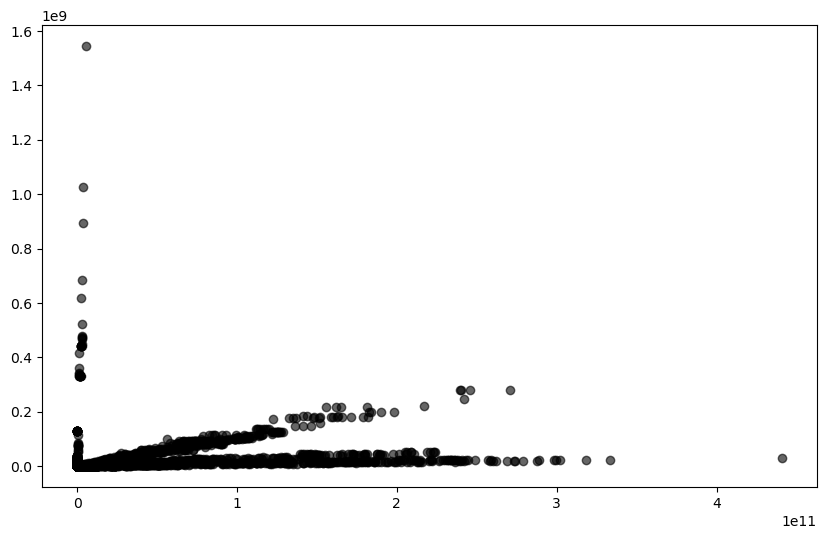

In [47]:
# Preparando o gráfico
plt.figure(figsize=(10, 6))

# Plotando os dados reais
plt.scatter(X_test, y_test, color='black', label='Dados Reais', alpha=0.6)

In [ ]:
# Treinamento dos modelos e avaliação
for name, model in models.items():
    # Treinando o modelo
    model.fit(X_train_scaled, y_train)
    
    # Realizando previsões
    y_pred = model.predict(X_test_scaled)
    
    # Plotando a linha de previsão com o label apropriado
    plt.plot(X_test, y_pred, label=f'{name} - Previsão')
    
    # Calculando o erro quadrático médio (MSE)
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name} - MSE: {mse}")

Regressão Linear - MSE: 411469279052984.5
Random Forest Regressor - MSE: 489689064653631.5


In [ ]:
# Personalizando o gráfico
plt.title('Previsões de Modelos vs Dados Reais')
plt.xlabel('Valor do Estoque')
plt.ylabel('Quantidade do Estoque')
plt.legend()
plt.grid(True)

# Exibindo o gráfico
plt.show()